In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, utils, metrics
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Install kaggle
!pip install -q kaggle

# Upload kaggle.json (you'll get a button)
from google.colab import files
files.upload()

# Setup kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download + unzip dataset
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 291MB/s]



In [ ]:
train_ds = utils.image_dataset_from_directory("/content/seg_train/seg_train", image_size = (128, 128), batch_size = 32, seed = 123)

Found 14034 files belonging to 6 classes.


In [ ]:
class_names = train_ds.class_names

In [ ]:
num_batches = len(train_ds)

In [ ]:
test_size = int(0.1 * num_batches)

In [ ]:
test_ds = train_ds.take(test_size)
train_ds = train_ds.skip(test_size)

In [ ]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
val_ds = utils.image_dataset_from_directory("/content/seg_test/seg_test", image_size = (128, 128), batch_size = 32, shuffle = False)

Found 3000 files belonging to 6 classes.


In [ ]:
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
def residual_block(x, filters):

    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    if (shortcut[-1].shape != filters):
        shortcut = layers.Conv2D(filters, (1, 1), padding = 'same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     x = layers.RandomFlip("horizontal")(inputs)
     x = layers.RandomRotation(0.1)(x)
     x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(inputs)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_model = conv_model((128, 128, 3))

In [ ]:
resnet_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = resnet_model.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 102s 189ms/step - accuracy: 0.6449 - loss: 0.8951 - val_accuracy: 0.3690 - val_loss: 3.0255
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 70s 173ms/step - accuracy: 0.7726 - loss: 0.6102 - val_accuracy: 0.6310 - val_loss: 1.7527
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8149 - loss: 0.5100 - val_accuracy: 0.6593 - val_loss: 1.1264
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.8247 - loss: 0.4756 - val_accuracy: 0.7420 - val_loss: 0.8076
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 168ms/step - accuracy: 0.8448 - loss: 0.4274 - val_accuracy: 0.7477 - val_loss: 0.7049
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 68s 168ms/step - accuracy: 0.8515 - loss: 0.4157 - val_accuracy: 0.6330 - val_loss: 1.4524
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 69s 172ms/step - accuracy: 0.8608 - loss: 0.3880 - val_accuracy: 0.8090 - val_loss: 0.6548
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 168ms/step - accuracy: 0.8651 - loss: 

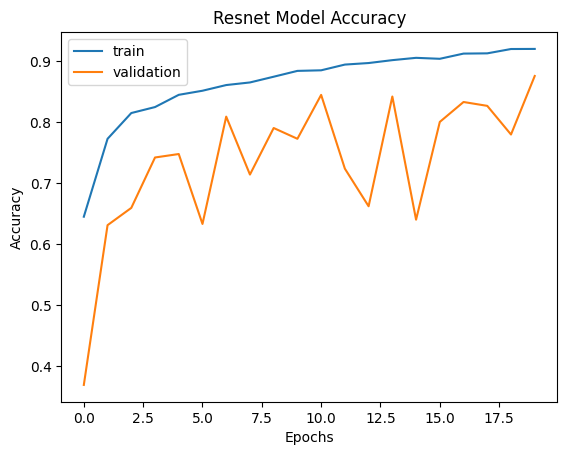

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

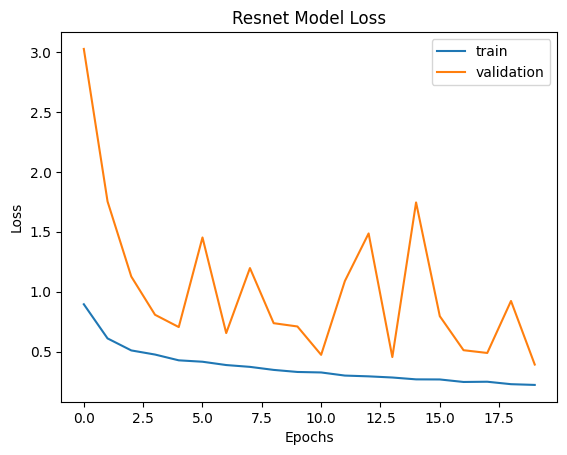

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_model.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━

In [ ]:
print(len(y_true), len(y_pred))

1376 1376


In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[177   2   2   0   7  25]
 [  0 215   0   2   0   0]
 [  2   3 228  15  16   0]
 [  0   2  43 193  10   0]
 [  1   1   5   2 213   0]
 [ 10   2   8   0   7 185]]
              precision    recall  f1-score   support

   buildings       0.93      0.83      0.88       213
      forest       0.96      0.99      0.97       217
     glacier       0.80      0.86      0.83       264
    mountain       0.91      0.78      0.84       248
         sea       0.84      0.96      0.90       222
      street       0.88      0.87      0.88       212

    accuracy                           0.88      1376
   macro avg       0.89      0.88      0.88      1376
weighted avg       0.88      0.88      0.88      1376



# Resnet without data **augmentation**

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     # x = layers.RandomFlip("horizontal")(inputs)
     # x = layers.RandomRotation(0.1)(x)
     # x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(inputs)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_no_data_aug = conv_model((128, 128, 3))

In [ ]:
resnet_no_data_aug.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history1 = resnet_no_data_aug.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 97s 195ms/step - accuracy: 0.6293 - loss: 0.9316 - val_accuracy: 0.4347 - val_loss: 1.7807
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - accuracy: 0.7788 - loss: 0.6054 - val_accuracy: 0.6017 - val_loss: 1.2407
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8075 - loss: 0.5209 - val_accuracy: 0.7080 - val_loss: 0.8972
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8328 - loss: 0.4645 - val_accuracy: 0.6647 - val_loss: 1.3320
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 169ms/step - accuracy: 0.8452 - loss: 0.4340 - val_accuracy: 0.8230 - val_loss: 0.5233
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8525 - loss: 0.4104 - val_accuracy: 0.7493 - val_loss: 0.7721
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8629 - loss: 0.3875 - val_accuracy: 0.8073 - val_loss: 0.5597
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8725 - loss: 0

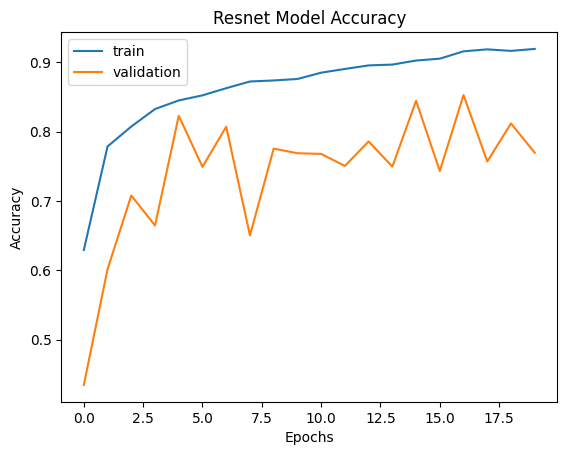

In [ ]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

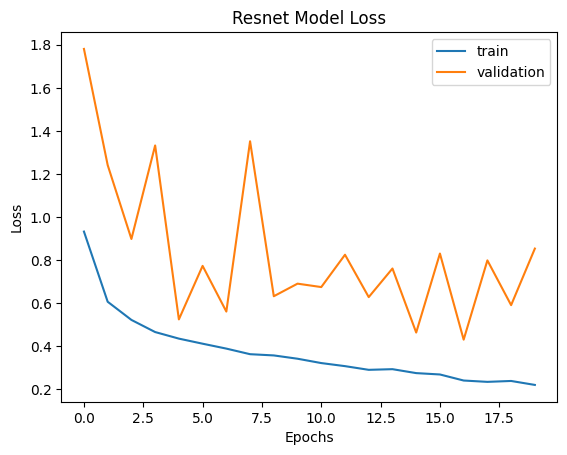

In [ ]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_no_data_aug.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━

In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[179   0  20   0   0  21]
 [  1 153  36   0  25   2]
 [  0   1 229  18  10   2]
 [  0   0  80 159   8   0]
 [  1   0  23   8 185   0]
 [  7   1   8   0   1 198]]
              precision    recall  f1-score   support

   buildings       0.95      0.81      0.88       220
      forest       0.99      0.71      0.82       217
     glacier       0.58      0.88      0.70       260
    mountain       0.86      0.64      0.74       247
         sea       0.81      0.85      0.83       217
      street       0.89      0.92      0.90       215

    accuracy                           0.80      1376
   macro avg       0.85      0.80      0.81      1376
weighted avg       0.84      0.80      0.81      1376



# Resnet without **dropout**

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     x = layers.RandomFlip("horizontal")(inputs)
     x = layers.RandomRotation(0.1)(x)
     x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(inputs)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     # x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_no_dropout = conv_model((128, 128, 3))

In [ ]:
resnet_no_dropout.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history2 = resnet_no_dropout.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 96s 196ms/step - accuracy: 0.6914 - loss: 0.8031 - val_accuracy: 0.5663 - val_loss: 1.4617
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - accuracy: 0.8015 - loss: 0.5447 - val_accuracy: 0.7103 - val_loss: 0.7790
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.8245 - loss: 0.4704 - val_accuracy: 0.7300 - val_loss: 0.8051
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8427 - loss: 0.4372 - val_accuracy: 0.5233 - val_loss: 2.0913
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 168ms/step - accuracy: 0.8574 - loss: 0.3974 - val_accuracy: 0.7063 - val_loss: 0.8775
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 68s 169ms/step - accuracy: 0.8662 - loss: 0.3724 - val_accuracy: 0.7317 - val_loss: 0.8872
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 169ms/step - accuracy: 0.8735 - loss: 0.3515 - val_accuracy: 0.5217 - val_loss: 2.7881
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 68s 170ms/step - accuracy: 0.8787 - loss: 0

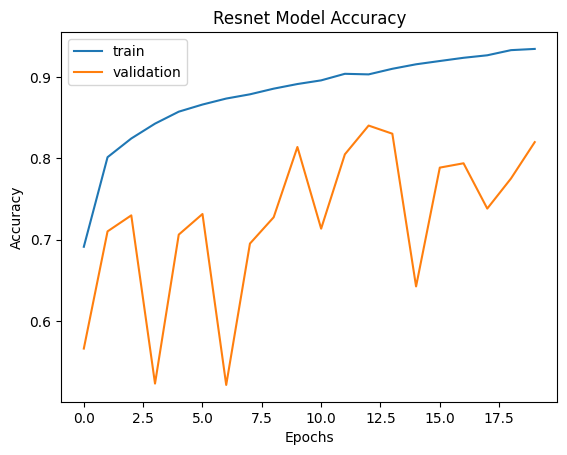

In [ ]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

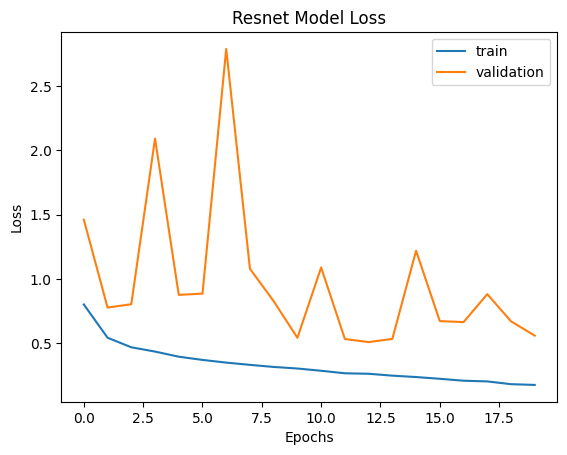

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_no_dropout.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━

In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[199   1   0   1  10   6]
 [  5 204  10   1   3   2]
 [  3   2 206  28  18   0]
 [  4   0  33 197  16   0]
 [  1   0   9   5 195   0]
 [ 49   0  11   0   6 151]]
              precision    recall  f1-score   support

   buildings       0.76      0.92      0.83       217
      forest       0.99      0.91      0.94       225
     glacier       0.77      0.80      0.78       257
    mountain       0.85      0.79      0.82       250
         sea       0.79      0.93      0.85       210
      street       0.95      0.70      0.80       217

    accuracy                           0.84      1376
   macro avg       0.85      0.84      0.84      1376
weighted avg       0.85      0.84      0.84      1376



# Resnet with different learning **rate**

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     x = layers.RandomFlip("horizontal")(inputs)
     x = layers.RandomRotation(0.1)(x)
     x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(inputs)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_diff_learning_rate = conv_model((128, 128, 3))

In [ ]:
resnet_diff_learning_rate.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history3 = resnet_diff_learning_rate.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 99s 199ms/step - accuracy: 0.6311 - loss: 0.9386 - val_accuracy: 0.3820 - val_loss: 1.7878
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - accuracy: 0.7626 - loss: 0.6445 - val_accuracy: 0.7187 - val_loss: 0.7792
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.7943 - loss: 0.5713 - val_accuracy: 0.7350 - val_loss: 0.6926
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 169ms/step - accuracy: 0.8201 - loss: 0.5080 - val_accuracy: 0.8117 - val_loss: 0.5197
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 68s 169ms/step - accuracy: 0.8288 - loss: 0.4769 - val_accuracy: 0.7947 - val_loss: 0.5917
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 168ms/step - accuracy: 0.8395 - loss: 0.4488 - val_accuracy: 0.8417 - val_loss: 0.4411
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 168ms/step - accuracy: 0.8505 - loss: 0.4232 - val_accuracy: 0.8300 - val_loss: 0.5042
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.8625 - loss: 0

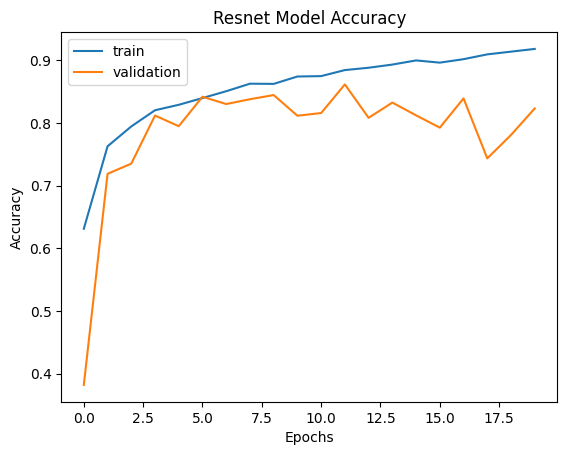

In [ ]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

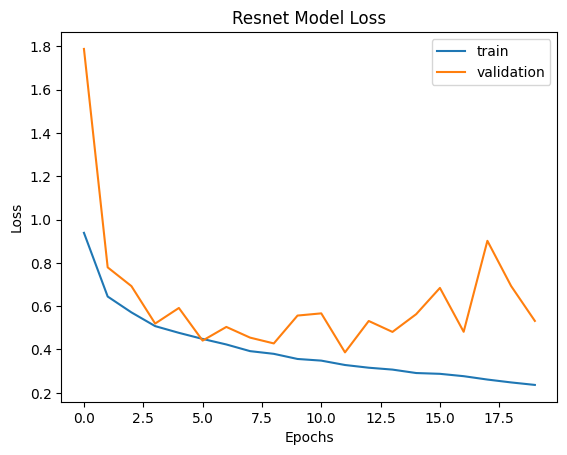

In [ ]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_diff_learning_rate.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━

In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[211   0   0   0   2  12]
 [ 12 176   4   2   2  23]
 [  2   1 219  22   6   2]
 [  4   0  54 180   5   0]
 [  6   0  14  12 188   0]
 [ 32   0   2   0   1 182]]
              precision    recall  f1-score   support

   buildings       0.79      0.94      0.86       225
      forest       0.99      0.80      0.89       219
     glacier       0.75      0.87      0.80       252
    mountain       0.83      0.74      0.78       243
         sea       0.92      0.85      0.89       220
      street       0.83      0.84      0.83       217

    accuracy                           0.84      1376
   macro avg       0.85      0.84      0.84      1376
weighted avg       0.85      0.84      0.84      1376

